In [1]:
import os
import random
import time
import copy
import numpy as np
import json
import yaml
from collections import Counter
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import ImageFile, Image
from dvclive import Live
import warnings

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

with open('params.yaml', encoding='utf-8') as f:
    params = yaml.safe_load(f)

numEpochs    = params['numEpochs']
batchSize    = params['batchSize']
learningRate = params['learningRate']
randomSeed   = params['randomSeed']
testSize     = params['testSize']
modelName  = params['model']
print("Модель для обучения:", modelName)

random.seed(randomSeed)
np.random.seed(randomSeed)
torch.manual_seed(randomSeed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

c:\Python\lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Модель для обучения: MobileNetV3_Small
Device: cpu


### Трансформации для изображений

In [2]:
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
testTransform = transforms.Compose([
    transforms.Resize(int(224*1.14)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

### Загрузка датасета

Размер полного датасета: 3068
Классы: ['Гаички', 'Домовый воробей', 'Красный кардинал', 'Кряква', 'Обыкновенный скворец']


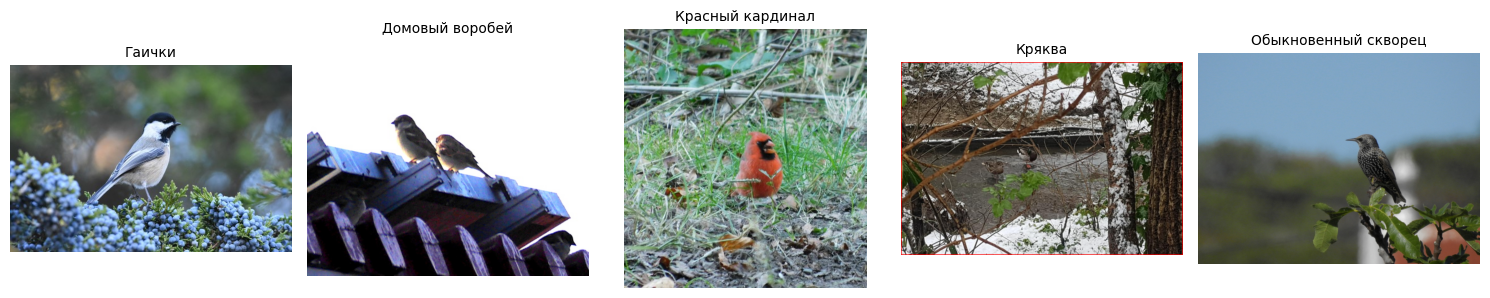

In [3]:
dataDir = './datasets/birds'

fullDataset = datasets.ImageFolder(dataDir, transform=trainTransform)
numClasses = len(fullDataset.classes)

print("Размер полного датасета:", len(fullDataset))
print("Классы:", fullDataset.classes)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes = axes.ravel()

imagesPerClass = {}
for path, label in fullDataset.samples:
    if label not in imagesPerClass:
        imagesPerClass[label] = path
    if len(imagesPerClass) == numClasses:
        break

for idx, (label, imgPath) in enumerate(imagesPerClass.items()):
    imgObject = Image.open(imgPath)
    axes[idx].imshow(imgObject)
    axes[idx].set_title(fullDataset.classes[label], fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Дисбаланс классов

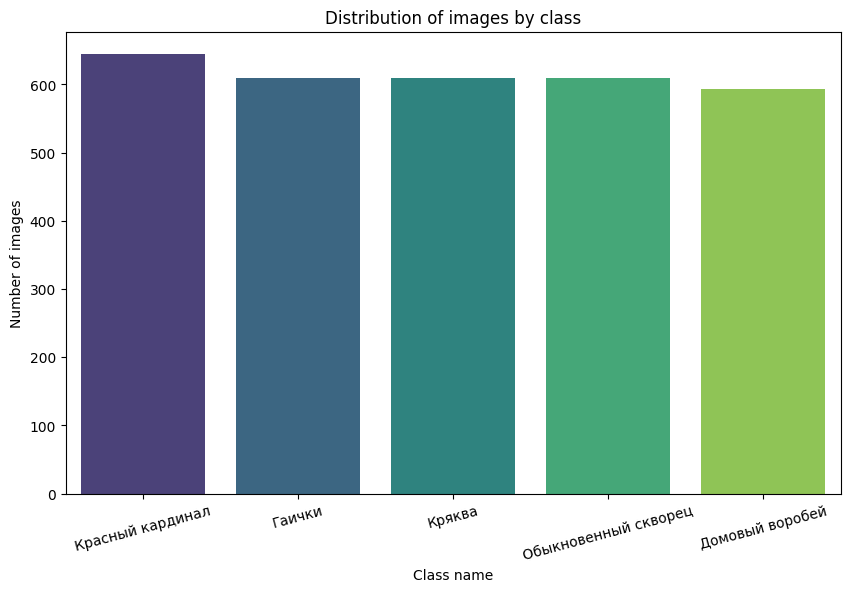

   count             classCame
2    645      Красный кардинал
0    610                Гаички
3    610                Кряква
4    610  Обыкновенный скворец
1    593       Домовый воробей


In [4]:
classCounts = Counter([label for _, label in fullDataset.samples])
countDf = pd.DataFrame.from_dict(classCounts, orient='index', columns=['count']).sort_values('count', ascending=False)
countDf['classCame'] = [fullDataset.classes[i] for i in countDf.index]

plt.figure(figsize=(10,6))
sns.barplot(data=countDf, x='classCame', y='count', palette='viridis', hue='classCame')
plt.title('Distribution of images by class')
plt.xticks(rotation=15)
plt.xlabel('Class name')
plt.ylabel('Number of images')
plt.show()

print(countDf)

### DataLoaders

In [5]:
def getBirdDataLoaders(testSize=0.2, batchSize=32, randomState=42, numWorkers=0):
    fullDatasetLocal = datasets.ImageFolder(dataDir, transform=testTransform)

    trainSize = int((1 - testSize) * len(fullDatasetLocal))
    testSizeActual = len(fullDatasetLocal) - trainSize
    trainDataset, testDataset = random_split(fullDatasetLocal, [trainSize, testSizeActual], generator=torch.Generator().manual_seed(randomState))

    trainDataset.dataset.transform = trainTransform
    testDataset.dataset.transform = testTransform

    trainLoader = DataLoader(
        trainDataset,
        batch_size=batchSize,
        shuffle=True,
        num_workers=numWorkers
    )

    testLoader = DataLoader(
        testDataset,
        batch_size=batchSize,
        shuffle=False,
        num_workers=numWorkers
    )
    
    return trainLoader, testLoader, trainDataset, testDataset

In [6]:
trainLoader, testLoader, trainDataset, testDataset = getBirdDataLoaders(testSize=testSize, batchSize=32, numWorkers=2)

print(f"Train size: {len(trainDataset)}")
print(f"Test size: {len(testDataset)}")

batchFeatures, batchLabels = next(iter(trainLoader))
print(f"Batch features shape: {batchFeatures.shape}, labels shape: {batchLabels.shape}")

Train size: 2454
Test size: 614
Batch features shape: torch.Size([32, 3, 224, 224]), labels shape: torch.Size([32])


### Кастомная модель BirdCNN

In [7]:
class BirdCNN(nn.Module):
    def __init__(self, numClasses=5):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, numClasses)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Создание моделей

In [8]:
def createModelByName(modelName: str, numClasses: int):
    if modelName == "BirdCNN":
        modelInstance = BirdCNN(numClasses=numClasses)
        return modelInstance.to(device)
    
    if modelName == "ResNet18":
        pretrainedModel = models.resnet18(pretrained=True)
        numFeatures = pretrainedModel.fc.in_features
        pretrainedModel.fc = nn.Linear(numFeatures, numClasses)
        for nameParam, param in pretrainedModel.named_parameters():
            if "fc" not in nameParam:
                param.requires_grad = False
        return pretrainedModel.to(device)
    
    if modelName == "EfficientNetB0":
        pretrainedModel = models.efficientnet_b0(pretrained=True)
        numFeatures = pretrainedModel.classifier[1].in_features
        pretrainedModel.classifier[1] = nn.Linear(numFeatures, numClasses)
        for nameParam, param in pretrainedModel.named_parameters():
            if "classifier" not in nameParam:
                param.requires_grad = False
        return pretrainedModel.to(device)

    if modelName == "DenseNet121":
        pretrainedModel = models.densenet121(pretrained=True)
        numFeatures = pretrainedModel.classifier.in_features
        pretrainedModel.classifier = nn.Linear(numFeatures, numClasses)
        for nameParam, param in pretrainedModel.named_parameters():
            if "classifier" not in nameParam:
                param.requires_grad = False
        return pretrainedModel.to(device)
    
    if modelName == "MobileNetV3_Small":
        pretrainedModel = models.mobilenet_v3_small(pretrained=True)
        numFeatures = pretrainedModel.classifier[0].in_features if isinstance(pretrainedModel.classifier, nn.Sequential) else pretrainedModel.classifier.in_features
        pretrainedModel.classifier = nn.Sequential(
            nn.Linear(numFeatures, numClasses)
        )
        for nameParam, param in pretrainedModel.named_parameters():
            if "classifier" not in nameParam:
                param.requires_grad = False
        return pretrainedModel.to(device)

    raise ValueError(f"Unknown modelName: {modelName}")

### Функции обучения и оценки

In [9]:
def trainOneEpoch(modelNet, dataLoaderTrain, optimizerAdam, criterionLoss):
    modelNet.train()
    runningLoss = 0.0
    runningSamples = 0
    allPredictions = []
    allTargets = []

    for batchFeatures, batchLabels in dataLoaderTrain:
        batchFeatures = batchFeatures.to(device)
        batchLabels = batchLabels.to(device)

        optimizerAdam.zero_grad()
        logits = modelNet(batchFeatures)
        lossValue = criterionLoss(logits, batchLabels)
        lossValue.backward()
        optimizerAdam.step()

        batchSize = batchFeatures.size(0)
        runningLoss += lossValue.item() * batchSize
        runningSamples += batchSize

        preds = torch.argmax(logits, dim=1)
        allPredictions.append(preds.detach().cpu().numpy())
        allTargets.append(batchLabels.detach().cpu().numpy())

    epochLoss = runningLoss / runningSamples

    allPredictions = np.concatenate(allPredictions)
    allTargets = np.concatenate(allTargets)
    accuracyOverall = (allPredictions == allTargets).mean()
    
    return epochLoss, accuracyOverall

In [10]:
def evaluateModel(modelNet, dataLoaderEval):
    modelNet.eval()
    criterionLoss = nn.CrossEntropyLoss()
    runningLoss = 0.0
    runningSamples = 0
    allPredictions = []
    allTargets = []

    with torch.no_grad():
        for batchFeatures, batchLabels in dataLoaderEval:
            batchFeatures = batchFeatures.to(device)
            batchLabels = batchLabels.to(device)

            logits = modelNet(batchFeatures)
            lossValue = criterionLoss(logits, batchLabels)

            batchSize = batchFeatures.size(0)
            runningLoss += lossValue.item() * batchSize
            runningSamples += batchSize

            preds = torch.argmax(logits, dim=1)
            allPredictions.append(preds.cpu().numpy())
            allTargets.append(batchLabels.cpu().numpy())

    epochLoss = runningLoss / runningSamples
    allPredictions = np.concatenate(allPredictions)
    allTargets = np.concatenate(allTargets)
    accuracyOverall = (allPredictions == allTargets).mean()

    return epochLoss, accuracyOverall, allTargets, allPredictions

In [11]:
def trainAndEvaluateModel(modelName: str, numEpochs: int = 10, batchSize: int = 16, learningRate: float = 1e-3):
    print("="*80)
    print(f"Запуск: {modelName}")
    trainLoaderLocal, testLoaderLocal, trainDatasetLocal, testDatasetLocal = getBirdDataLoaders(testSize=0.2,
                                                                                               batchSize=batchSize,
                                                                                               randomState=randomSeed)
    numClassesLocal = len(trainDatasetLocal.dataset.classes)
    modelInstance = createModelByName(modelName, numClassesLocal)

    optimizerLocal = optim.Adam(filter(lambda p: p.requires_grad, modelInstance.parameters()),
                                lr=learningRate,
                                weight_decay=1e-4)
    criterionLocal = nn.CrossEntropyLoss()

    trainLossHistoryLocal = []
    trainAccuracyHistoryLocal = []
    testLossHistoryLocal = []
    testAccuracyHistoryLocal = []

    bestTestAccuracyLocal = 0.0
    bestModelStateLocal = None
    bestEpochLocal = 0

    startTime = time.time()
    for epochIndex in range(1, numEpochs+1):
        trainLoss, trainAccuracy = trainOneEpoch(modelInstance, trainLoaderLocal, optimizerLocal, criterionLocal)
        testLoss, testAccuracy, _, _ = evaluateModel(modelInstance, testLoaderLocal)

        trainLossHistoryLocal.append(trainLoss)
        trainAccuracyHistoryLocal.append(trainAccuracy)
        testLossHistoryLocal.append(testLoss)
        testAccuracyHistoryLocal.append(testAccuracy)

        if testAccuracy > bestTestAccuracyLocal:
            bestTestAccuracyLocal = testAccuracy
            bestModelStateLocal = copy.deepcopy(modelInstance.state_dict())
            bestEpochLocal = epochIndex
        
        if epochIndex % 1 == 0 or epochIndex == 1:
            print(f"{modelName} | Epoch {epochIndex:03d} | trainLoss = {trainLoss:.4f} | testLoss = {testLoss:.4f} | trainAcc = {trainAccuracy:.4f} | testAcc = {testAccuracy:.4f}")

    elapsedTime = time.time() - startTime
    testLossFinal, testAccuracyFinal, allTargetsLocal, allPredictionsLocal = evaluateModel(modelInstance, testLoaderLocal)

    confusionMatrixLocal = confusion_matrix(allTargetsLocal, allPredictionsLocal)
    classNamesLocal = testDatasetLocal.dataset.classes
    classificationReportLocal = classification_report(allTargetsLocal, allPredictionsLocal, target_names=classNamesLocal, digits=4, output_dict=False)

    if bestModelStateLocal is not None:
        torch.save(bestModelStateLocal, f'./models/best_{modelName}.pth')
        print(f"Сохранена лучшая модель {modelName} на эпохе {bestEpochLocal}")

    resultDict = {
        "modelName": modelName,
        "numEpochs": numEpochs,
        "batchSize": batchSize,
        "learningRate": learningRate,
        "trainLossHistory": trainLossHistoryLocal,
        "trainAccuracyHistory": trainAccuracyHistoryLocal,
        "testLossHistory": testLossHistoryLocal,
        "testAccuracyHistory": testAccuracyHistoryLocal,
        "bestTestAccuracy": bestTestAccuracyLocal,
        "bestEpoch": bestEpochLocal,
        "finalTestLoss": testLossFinal,
        "finalTestAccuracy": testAccuracyFinal,
        "confusionMatrix": confusionMatrixLocal,
        "classificationReportText": classificationReportLocal,
        "classNames": classNamesLocal,
        "elapsedTimeSeconds": elapsedTime
    }
    
    return resultDict

### Запуск обучения

In [13]:
with Live(save_dvc_exp=True, dvcyaml=False, exp_message=f"run {modelName}") as live:
    live.log_param("numEpochs", numEpochs)
    live.log_param("batchSize", batchSize)
    live.log_param("learningRate", learningRate)
    live.log_param("randomSeed", randomSeed)
    live.log_param("testSize", testSize)
    live.log_param("model", modelName)

    result = trainAndEvaluateModel(
        modelName,
        numEpochs=numEpochs,
        batchSize=batchSize,
        learningRate=learningRate
    )

    live.log_metric("best_test_accuracy", result["bestTestAccuracy"])
    live.log_metric("final_test_accuracy", result["finalTestAccuracy"])
    live.log_metric("final_test_loss", result["finalTestLoss"])
    live.log_metric("elapsed_time_seconds", result["elapsedTimeSeconds"])

    for epoch in range(numEpochs):
        live.step = epoch

        live.log_metric("train_loss", result["trainLossHistory"][epoch], plot=True)
        live.log_metric("train_accuracy", result["trainAccuracyHistory"][epoch], plot=True)
        live.log_metric("test_loss", result["testLossHistory"][epoch], plot=True)
        live.log_metric("test_accuracy", result["testAccuracyHistory"][epoch], plot=True)

        live.make_summary()

    confusionPath = f"{modelName}_confusion.csv"
    np.savetxt(confusionPath, result["confusionMatrix"], delimiter=",", fmt="%d")
    live.log_artifact(confusionPath, type="table", name=f"{modelName}_confusion")

print("\nМетрики и графики сохранены в animals/dvclive/")


Запуск: MobileNetV3_Small
MobileNetV3_Small | Epoch 001 | trainLoss = 1.1408 | testLoss = 0.7468 | trainAcc = 0.5970 | testAcc = 0.7671
MobileNetV3_Small | Epoch 002 | trainLoss = 0.7866 | testLoss = 0.6780 | trainAcc = 0.7433 | testAcc = 0.7655
MobileNetV3_Small | Epoch 003 | trainLoss = 0.6975 | testLoss = 0.6172 | trainAcc = 0.7551 | testAcc = 0.7801
MobileNetV3_Small | Epoch 004 | trainLoss = 0.6515 | testLoss = 0.6054 | trainAcc = 0.7730 | testAcc = 0.7915
MobileNetV3_Small | Epoch 005 | trainLoss = 0.5993 | testLoss = 0.5664 | trainAcc = 0.7901 | testAcc = 0.8078
MobileNetV3_Small | Epoch 006 | trainLoss = 0.5935 | testLoss = 0.5500 | trainAcc = 0.7889 | testAcc = 0.8127
MobileNetV3_Small | Epoch 007 | trainLoss = 0.5593 | testLoss = 0.5506 | trainAcc = 0.7967 | testAcc = 0.8013
MobileNetV3_Small | Epoch 008 | trainLoss = 0.5362 | testLoss = 0.5397 | trainAcc = 0.8174 | testAcc = 0.8029
MobileNetV3_Small | Epoch 009 | trainLoss = 0.5383 | testLoss = 0.5371 | trainAcc = 0.8052 | t

	animals/output.txt



Метрики и графики сохранены в animals/dvclive/


### Результаты

In [18]:
summaryRow = {
    "modelName": modelName,
    "bestTestAccuracy": result["bestTestAccuracy"],
    "finalTestAccuracy": result["finalTestAccuracy"],
    "finalTestLoss": result["finalTestLoss"],
    "elapsedTimeSeconds": result["elapsedTimeSeconds"]
}

summaryDf = pd.DataFrame([summaryRow])

display(summaryDf)

print("\n" + "=" * 80)
print(
    f"Модель: {modelName} | "
    f"bestTestAccuracy={result['bestTestAccuracy']:.4f} | "
    f"finalTestAccuracy={result['finalTestAccuracy']:.4f}\n"
)

classNames = result["classNames"]
confusionMatrix = result["confusionMatrix"]

accuracyPerClass = confusionMatrix.diagonal() / confusionMatrix.sum(axis=1)

for classIndex, classAccuracy in enumerate(accuracyPerClass):
    print(f"Class '{classNames[classIndex]}': accuracy = {classAccuracy:.4f}")

print("\nClassification report:\n")
print(result["classificationReportText"])

print("\nConfusion Matrix:\n")
print(confusionMatrix)

print("=" * 80 + "\n")


,modelName,bestTestAccuracy,finalTestAccuracy,finalTestLoss,elapsedTimeSeconds
0,MobileNetV3_Small,0.815961,0.815961,0.52539,136.993627



Модель: MobileNetV3_Small | bestTestAccuracy=0.8160 | finalTestAccuracy=0.8160

Class 'Гаички': accuracy = 0.8209
Class 'Домовый воробей': accuracy = 0.6609
Class 'Красный кардинал': accuracy = 0.8692
Class 'Кряква': accuracy = 0.8496
Class 'Обыкновенный скворец': accuracy = 0.8689

Classification report:

                      precision    recall  f1-score   support

              Гаички     0.8871    0.8209    0.8527       134
     Домовый воробей     0.7379    0.6609    0.6972       115
    Красный кардинал     0.8248    0.8692    0.8464       130
              Кряква     0.8649    0.8496    0.8571       113
Обыкновенный скворец     0.7626    0.8689    0.8123       122

            accuracy                         0.8160       614
           macro avg     0.8154    0.8139    0.8132       614
        weighted avg     0.8171    0.8160    0.8150       614


Confusion Matrix:

[[110   6   4   4  10]
 [ 10  76  14   3  12]
 [  1  11 113   4   1]
 [  2   1   4  96  10]
 [  1   9   2   4 